# Curso Data Science Parte I - Trabajo Final

### Fraud Detection - Transacciones Bancarias

##### Este análisis se enfoca en un conjunto de datos detallado de transacciones bancarias, abarcando tanto las operaciones de débito como las de crédito realizadas por los clientes del mismo. La información incluye ciertos detalles que permiten una comprensión profunda de cada transacción financiera. Entre estos detalles se encuentran el monto, la fecha y hora en que se llevó a cabo, la ubicación geográfica desde donde se originó, el identificador único del dispositivo utilizado para realizar la operación, la identificación del comerciante que realizó el cobro y las características demográficas y laborales del titular de la cuenta. Adicionalmente, el dataset posee indicadores como el tipo de operación (crédito o débito) y el canal a través del cual se ejecutó (ya sea online, a través de un cajero automático o en una sucursal física).

##### El objetivo de este análisis es la identificación de patrones de comportamiento de los clientes y la detección de posibles anomalías que puedan servir como señales de actividades fraudulentas. A través de una exploración de estas variablesy sus correlaciones, se busca poder detectar insights importantes que contribuyan a la mejora de las estrategias de detección y prevención del fraude bancario. La capacidad de distinguir a las transacciones legítimas de aquellas que podrían ser posible fraude es fundamental para proteger tanto al banco como a sus clientes.

#### Las variables que integran este dataset son las siguientes:
###### * TransactionID: ID único por transacción.
###### * AccountID: ID único para cada cuenta, con múltiples transacciones por cuenta.
###### * TransactionAmount: monto en dolares de cada transacción.
###### * TransactionDate: fecha y hora de la transacción.
###### * TransactionType: Tipo de transacción, puede ser 'Credit' (Crédito) o 'Debit' (Débito).
###### * Location: Ubicación geográfica de la transacción, representada por nombres de ciudades de EE. UU.
###### * DeviceID: ID para los dispositivos utilizados para realizar la transacción.
###### * IP Address: Dirección IP asociada con la transacción.
###### * MerchantID: ID único para los comercios, mostrando comerciantes preferidos y atípicos para cada cuenta.
###### * AccountBalance: Saldo en la cuenta después de la transacción, con correlaciones lógicas basadas en el tipo y el monto de la transacción.
###### * PreviousTransactionDate: Marca de tiempo de la última transacción para la cuenta, lo que ayuda a calcular la frecuencia de las transacciones.
###### * Channel: Canal a través del cual se realizó la transacción (p. ej., Online, ATM, Branch).
###### * CustomerAge: Edad del titular de la cuenta, con agrupaciones lógicas basadas en la ocupación.
###### * CustomerOccupation: Ocupación del titular de la cuenta (p. ej., Doctor, Engineer, Student, Retired), lo que refleja patrones de ingresos.
###### * TransactionDuration: Duración de la transacción en segundos, que varía según el tipo de transacción.
###### * LoginAttempts: Número de intentos de inicio de sesión antes de la transacción, con valores más altos que indican posibles anomalías.

#### En base a esta información, buscaremos contestar las siguientes preguntas:
###### * ¿Cómo pordríamos distinguir un comportamiento "Normal" de uno "Anormal"?
###### * ¿Puede decirnos algo la cantidad de transacciónes por cuenta?
###### * ¿Puede haber una cantidad muy grande de transacciones pequeña que puedan ser fraude?
###### * ¿Existe alguna correlación entre edad, ocupación, montos, cantidad de transacciones o promedio de transacciones por día?
###### * ¿Es la ubicación Geográfica un factor que nos indique una correlación con el resto de las variables?


##### Para contestar estas preguntas, estructuraremos nuestro análisis en varias etapas clave. Inicialmente, procederemos a la importación de todas las librerias de Python que se consideren necesarias para llevar esta actividad adelante. A continuación, llevaremos a cabo un exhaustivo Análisis Exploratorio de Datos (EDA, por sus siglas en inglés), una fase clave que nos permitirá entender con mayor profundidad la estructura, las características y las particularidades de nuestro dataset. Finalmente, nos apoyaremos en la visualización de datos para representar la información de manera clara y concisa, facilitando así la identificación de patrones relevantes que puedan pasar desapercibidos en un análisis sólo numérico. Este enfoque nos permitirá maximizar las posibilidades de detectar indicios de fraude y contribuir a la seguridad de la institución.


#### Importación de librerías de Python:

In [42]:
import pandas as pd
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix




##### Con la ayuda de Pandas y Github, ejecutamos un "pd.read_csv" tomando como referencia la ruta "RAW" del .csv correspondiente al dataset, alojado en el repositorio que previamente habíamos creado.

In [9]:
url_del_dataset = 'https://raw.githubusercontent.com/lge93/proyecto_ds_coder/refs/heads/main/bank_transactions_data.csv'

df = pd.read_csv(url_del_dataset)
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


##### Revisamos con ".info()" la cantidad de columnas y registros que tiene el dataset y vemos que contiene 16 columnas y 2512 registros. Además podemos ver que no existen valores nulos en este conjunto de datos.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

##### Vemos que el campo "TransactionDate" es del tipo Object que en pandas está relacionado con strings por lo que lo pasaremos a tipo date para facilitar su uso. Además procederemos a calcular la fecha mínima y máxima para saber con qué rango de tiempo estamos trabajando.

In [12]:
#convertimos TransactionDate de object a date
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

#
fecha_minima = df['TransactionDate'].min()
fecha_maxima = df['TransactionDate'].max()

print(f"\nLa fecha mínima en 'Fecha_Registro' es: {fecha_minima}")
print(f"La fecha máxima en 'Fecha_Registro' es: {fecha_maxima}")


La fecha mínima en 'Fecha_Registro' es: 2023-01-02 16:00:06
La fecha máxima en 'Fecha_Registro' es: 2024-01-01 18:21:50


##### De esta forma podemos ver que el histórico de transacciones que tenemos va desde el 02/01/2023 al 01/01/2024 es decir, un año calendario entero.

##### Ahora veamos cuantos clientes distintos tenemos dentro de nuestro dataset, es decir nuestra población a estudiar:

In [13]:
#Usamos el método .nuique() para contar cuántos valores únicos del campo 'AccountID' tenemos. Este método nos devuelve un int.
cantidad_clientes_distintos = df['AccountID'].nunique()
cantidad_clientes_distintos

495

##### Con la función ".describe()" veremos un resumen de los estadísticos principales sobres las variables numéricas del set de datos.

In [14]:
df.describe()

,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,2023-07-05 20:32:10.826433024,44.673965,119.643312,1.124602,5114.302966
min,0.260000,2023-01-02 16:00:06,18.000000,10.000000,1.000000,101.250000
25%,81.885000,2023-04-03 16:22:05.750000128,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,2023-07-07 17:49:43.500000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,2023-10-06 18:40:53.500000,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,2024-01-01 18:21:50,80.000000,300.000000,5.000000,14977.990000
std,291.946243,NaN,17.792198,69.963757,0.602662,3900.942499


##### Estos indicadores estadísticos ya nos están dando muchos datos, entre ellos:

##### * Vemos que la desviación estándar del TransactionAmount es casi idéntico al promedio, por lo que podemos decir que hay una gran dispersión, o sea valores alejados de la media. Además también podemos ver que los valores máximo y mínimo están muy alejados del promedio lo que también nos indica que hay outliers o valores atípicos, eso podría indicar movimientos sospechosos.

##### * Siguiendo con la edad de los clientes vemos que el promedio está en los 45 años, la edad mínima está en 18 y el máximo en 80, lo cual nos indica que tenemos una buena variedad rangos etarios, esto nos servirá para analizar el comportamiento transaccional según la edad y poder hacer comparaciones entre los mismos. 

##### * En cuanto a la TransactionDuration vemos que hay mucha diferencia entre el quartil 75% que es de 161 y el máximo valor que es de 300 minutos. Duraciones más largas podrían indicar actividad fraudulenta.

##### * Mismo caso con LoginAttempts (intentos de login), vemos que hasta el 75% de la muestra la cantidad de intentos es 1, pero vemos que el máximo es 5, también podría estar indicando algún indicio de actividad sospechosa.

##### * En cuanto al AccountBalance (saldo de la cuenta) podemos decir que hay cuentas que tienen saldos muy pequeños (min= 100USD vs max= 15.000USD) esto podría servirnos para analizar el comportamiento entre cuentas que tienen bajos saldos vs las que tienen altos saldos, cantidad de transacciones, ubicación geográfica, rango etario, ocupación, etc.

### Distribución de las variables numéricas, apoyo visual.

##### Distribución de las transacciones por monto (TransactionAmount)
###### Gracias a éste histograma podemos ver claramente que el 75% de las transacciones están por debajo de los USD$400 

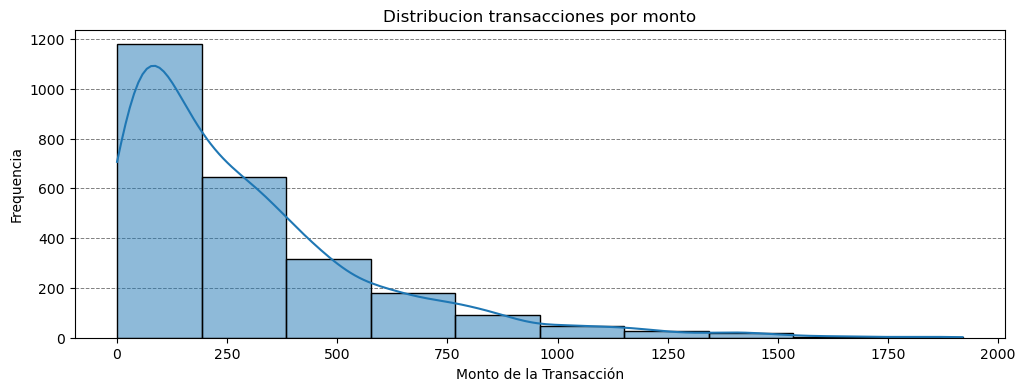

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.histplot(df['TransactionAmount'], bins=10, kde=True)
ax.set_title('Distribucion transacciones por monto')
ax.set_xlabel('Monto de la Transacción')
ax.set_ylabel('Frequencia')
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

##### Distribución de la población por edad
###### Acá claramente podemos ver que se respeta lo que habíamos visto en el método .describe(), si bien tenemos una mayor concentración en los rangos inferiores de entre 18 y 31 años, vemos que la distribución es bastante pareja en toda la serie.

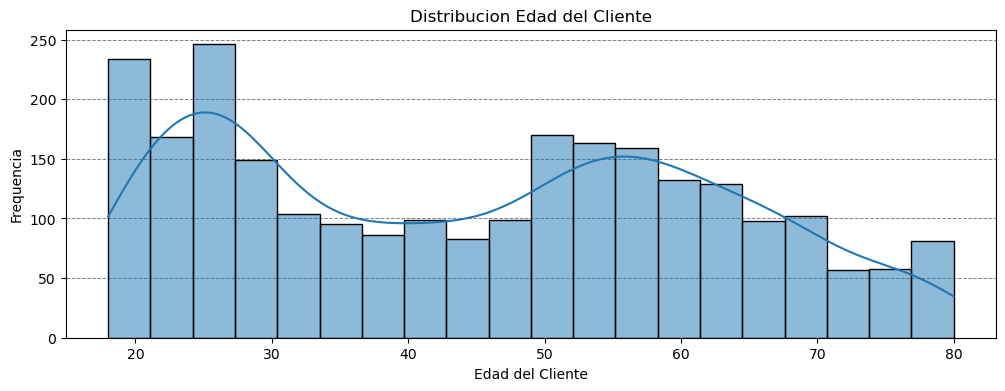

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.histplot(df['CustomerAge'], bins=20, kde=True)
ax.set_title('Distribucion Edad del Cliente')
ax.set_xlabel('Edad del Cliente')
ax.set_ylabel('Frequencia')
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

##### Distribución por duración de la transacción (TransactionDuration)
###### En este caso vemos que la duración de la transacción es bastante pareja hasta los 160 minutos pero a partir de ese valor baja repentinamente hasta llegar al valor máximo de la serie que está en 300 minutos.

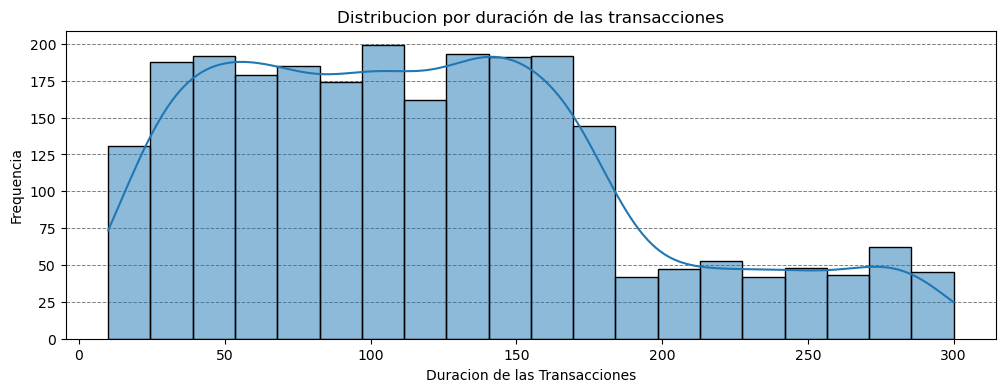

In [17]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.histplot(df['TransactionDuration'], bins=20, kde=True)
ax.set_title('Distribucion por duración de las transacciones')
ax.set_xlabel('Duracion de las Transacciones')
ax.set_ylabel('Frequencia')
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

##### Distribución por el saldo de la cuenta (AccountBalance)
###### Acá lo que podemos ver es que, como ya habíamos notado hay una gran diferencia entre los valores mínimos y máximos. Por otro lado, también podemos notar que hay una concentración en los saldos más pequeños hasta el orden de los USD$2000.

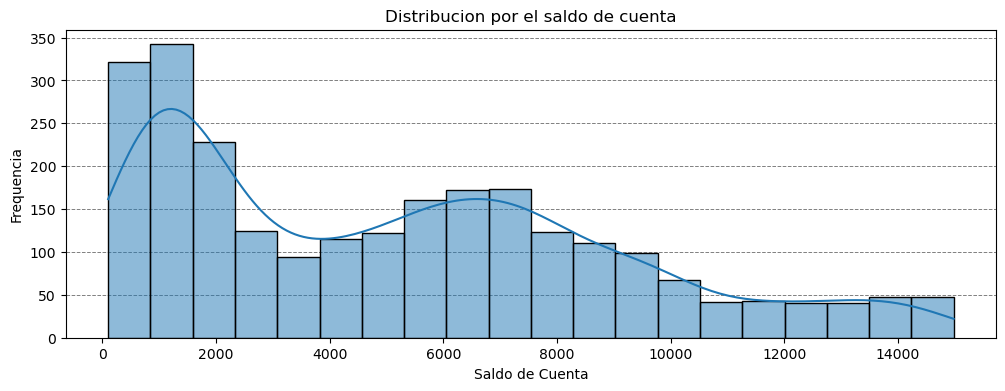

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.histplot(df['AccountBalance'], bins=20, kde=True)
ax.set_title('Distribucion por el saldo de cuenta')
ax.set_xlabel('Saldo de Cuenta')
ax.set_ylabel('Frequencia')
ax.set_axisbelow(True)
ax.grid(axis='y', color='gray', linestyle='--', linewidth=0.7)

##### Relación entre Edad, Balance de la cuenta y Monto de las transacciones
###### En este caso mediante scatterplots o gráficos de dispersión, podemos visualizar que hay una clara concentración de casos de clientes de entre 18 y 30 años que los balances de sus cuentas no superan los USD2000. Con esta referencia si pasamos al tercer scatterplot podemos decir que si vemos clientes con ese rango etario con transacciones de mas de USD1000 deberíamos tomarlas como dudosas. Asi mismo cuando vemos la relacion entre balance y monto de la transaccion vemos que la mayoría de las transacciones tienen un monto menor a UDS1000.

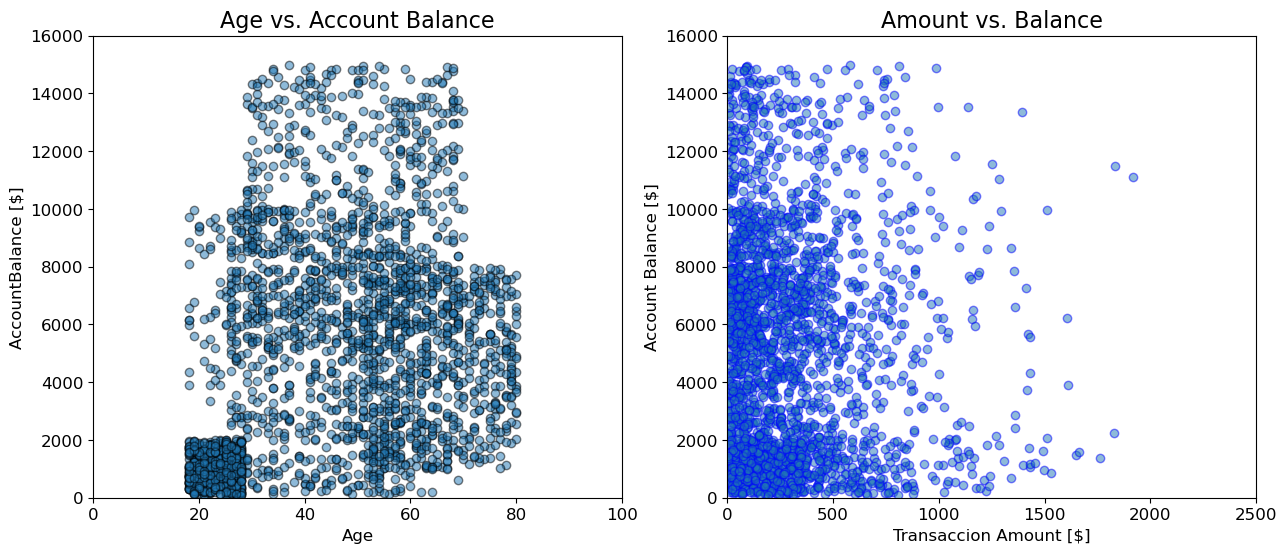

In [19]:
# Age vs Balance
plt.figure(figsize=(15,6))
plt.subplot(121)
# Hacemos un scatter plot
plt.scatter(df['CustomerAge'], df['AccountBalance'], edgecolor='k', alpha=0.5)
plt.ylim(0, 16000)
plt.yticks(fontsize=12)
plt.ylabel('AccountBalance [$]', fontsize=12)
plt.xticks(fontsize=12)
plt.xlim(0, 100)
plt.xlabel('Age', fontsize=12)
plt.title('Age vs. Account Balance', fontsize=16)

# Amount vs Balance
plt.subplot(122)
plt.scatter(df['TransactionAmount'], df['AccountBalance'], edgecolor='b', alpha=0.5)
plt.xlim(0, 2500)
plt.xlabel('Transaccion Amount [$]', fontsize=12)
plt.xticks(fontsize=12)
plt.ylim(0, 16000)
plt.ylabel('Account Balance [$]', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Amount vs. Balance', fontsize=16)
plt.show()

Text(0.5, 1.0, 'Age vs. Transaction Amount')

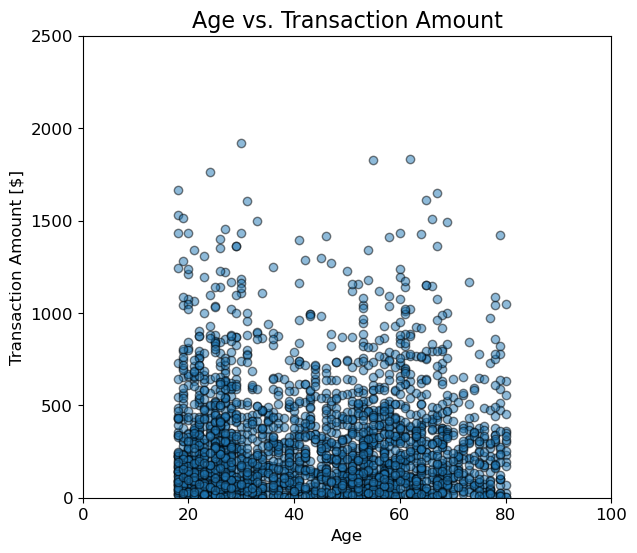

In [20]:
# Age vs Balance
plt.figure(figsize=(15,6))
plt.subplot(121)
# Hacemos un scatter plot
plt.scatter(df['CustomerAge'], df['TransactionAmount'], edgecolor='k', alpha=0.5)
plt.ylim(0, 2500)
plt.yticks(fontsize=12)
plt.ylabel('Transaction Amount [$]', fontsize=12)
plt.xticks(fontsize=12)
plt.xlim(0, 100)
plt.xlabel('Age', fontsize=12)
plt.title('Age vs. Transaction Amount', fontsize=16)

### Feature Engeneering

##### A modo de Feature Engeneering vamos a crear una nueva variable que nos servirá como target para entrenar un modelo supervisado de clasificación para detectar casos potencialmente sospechosos. 

##### Según el análisis que acabamos de hacer sobre las variables numéricas, y luego de haber alineado el criterio en conjunto con el negocio podemos considerar casos potencialmente sospechosos si cumplen con al menos uno de las siguientes condiciones:

##### * Edad entre 18 y 31 años con un monto de transacción mayor o igual a USD1000.
##### * Duración de la transacción de más de 160 minutos
##### * Más de 1 intento de login
##### * Cuentas con balances de menos de USD2000 y montos de transacción superiores a USD500

##### El resultado de esta segmentación será una variable binaria que tomará el valor de 1 cuando el cliente sea potencialmente sospechoso y 0 cuando sea no sospechoso.

In [21]:
# Condición 1.a: 
condicion_1a = df['CustomerAge'] <= 30

# Condición 1.b: 
condicion_1b = df['TransactionAmount'] >= 1000

# Condición 2:
condicion_2 = df['TransactionDuration'] >= 160

# Condición 3:
condicion_3 = df['LoginAttempts'] > 1

# Condición 4a:
condicion_4a = df['AccountBalance'] <= 2000

# Condición 4b:
condicion_4b = df['TransactionAmount'] >= 500 

df['ClienteSospechoso'] = np.where(
    (condicion_1a & condicion_1b) | condicion_2 | condicion_3 | (condicion_4a & condicion_4b) ,
    1,                                          
    0                                           
)

print(df.head(10))

  TransactionID AccountID  TransactionAmount     TransactionDate  \
0      TX000001   AC00128              14.09 2023-04-11 16:29:14   
1      TX000002   AC00455             376.24 2023-06-27 16:44:19   
2      TX000003   AC00019             126.29 2023-07-10 18:16:08   
3      TX000004   AC00070             184.50 2023-05-05 16:32:11   
4      TX000005   AC00411              13.45 2023-10-16 17:51:24   
5      TX000006   AC00393              92.15 2023-04-03 17:15:01   
6      TX000007   AC00199               7.08 2023-02-15 16:36:48   
7      TX000008   AC00069             171.42 2023-05-08 17:47:59   
8      TX000009   AC00135             106.23 2023-03-21 16:59:46   
9      TX000010   AC00385             815.96 2023-03-31 16:06:57   

  TransactionType       Location DeviceID       IP Address MerchantID Channel  \
0           Debit      San Diego  D000380   162.198.218.92       M015     ATM   
1           Debit        Houston  D000051      13.149.61.4       M052     ATM   
2       

##### Para continuar, crearemos un nuevo dataframe sólo con las variables que creemos que pueden ser relevantes para el desarrollo del modelo predictivo, además convertiremos las variables categóricas en variables numéricas utilizando el método one hot encoder.

In [25]:
df_modelo_fraude = df[['TransactionAmount',
                       'TransactionType',
                       'AccountBalance',
                       'Channel',
                       'CustomerAge',
                       'CustomerOccupation',
                       'TransactionDuration',
                       'LoginAttempts',
                       'ClienteSospechoso'
                       ]]
df_modelo_fraude.head()

,TransactionAmount,TransactionType,AccountBalance,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,ClienteSospechoso
0,14.09,Debit,5112.21,ATM,70,Doctor,81,1,0
1,376.24,Debit,13758.91,ATM,68,Doctor,141,1,0
2,126.29,Debit,1122.35,Online,19,Student,56,1,0
3,184.50,Debit,8569.06,Online,26,Student,25,1,0
4,13.45,Credit,7429.40,Online,26,Student,198,1,1


##### Para las variables categóricas 'TransactionType', 'Channel' y 'CustomerOccupation' tendremos que aplicar One Hot Encoder para transformarlas.

In [29]:

# Creamos el OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Transformamos las variables
categorical_columns = ['TransactionType', 'Channel', 'CustomerOccupation']
encoded_features = encoder.fit_transform(df_modelo_fraude[categorical_columns])

encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))

df_final = pd.concat([df_modelo_fraude.drop(categorical_columns, axis=1), encoded_df], axis=1)

print(df_final)


      TransactionAmount  AccountBalance  CustomerAge  TransactionDuration  \
0                 14.09         5112.21           70                   81   
1                376.24        13758.91           68                  141   
2                126.29         1122.35           19                   56   
3                184.50         8569.06           26                   25   
4                 13.45         7429.40           26                  198   
...                 ...             ...          ...                  ...   
2507             856.21        12690.79           33                  109   
2508             251.54          254.75           48                  177   
2509              28.63         3382.91           56                  146   
2510             185.97         1776.91           23                   19   
2511             243.08          131.25           24                   93   

      LoginAttempts  ClienteSospechoso  TransactionType_Credit  \
0        

##### Creamos la matriz de correlación para ver cómo se relacionan las distintas variables:

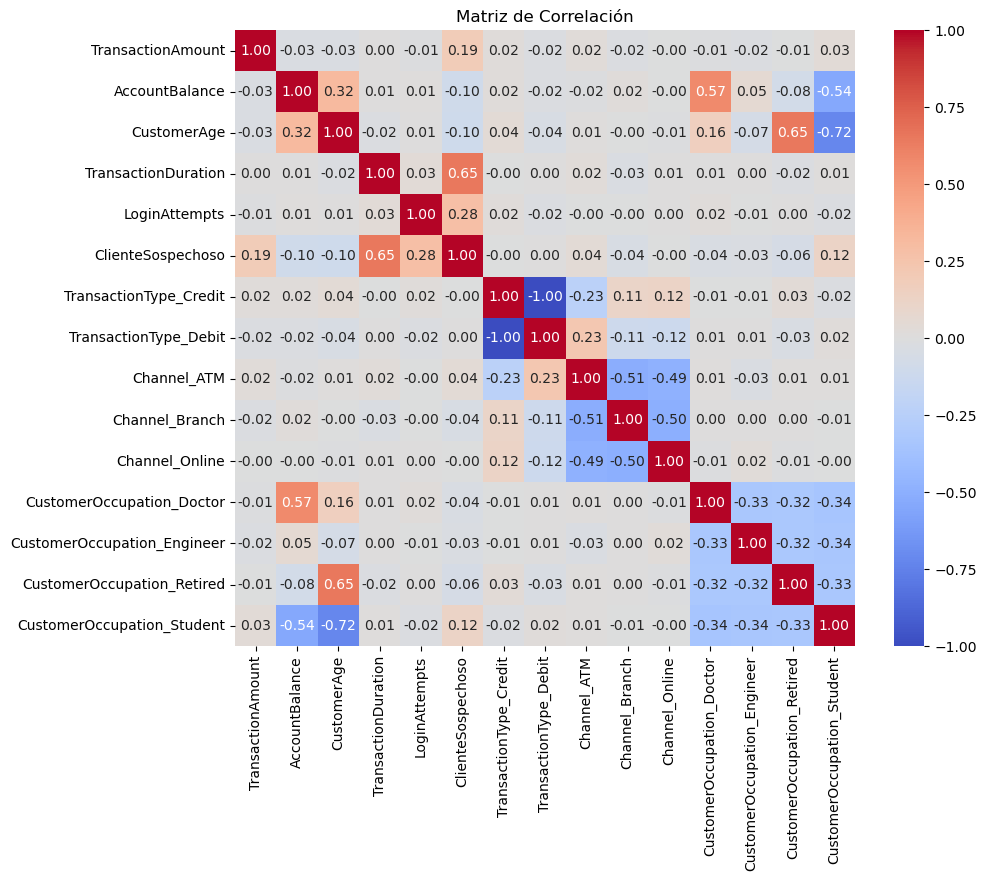

In [31]:
correlation_matrix = df_final.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()


##### Vemos que hay poca correlación entre las variables y la variable target. Esto puede ser malo para la predictividad del modelo aunque una correlación muy alta podría ser malo también ya que se generaría un sesgo.

In [32]:

# Separamos la variable objetivo del resto de features
X = df_final.drop('ClienteSospechoso', axis=1)
y = df_final['ClienteSospechoso']



In [52]:
# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#Probamos si el accuracy cambia usamos un test_size más grande


In [53]:
# entrenamos el modelo de arboles de decisión
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [54]:
# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)


In [55]:
# Evaluar el modelo

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)


Accuracy: 0.99
Precision: 1.00
Recall: 0.99
F1 Score: 0.99
Confusion Matrix:
[[513   1]
 [  3 237]]


##### En las celdas anteriores vemos que el accuracy es del 99%. Lejos de ser bueno, claramente estamos ante un caso de sobreajuste. Vemos también que en la matriz de confusión casi el 100% de los casos son predichos correctamente, lo cual nos indica que este modelo es muy bueno sobre los datos que tenemos hoy en día para entrenar y testear el modelo pero dificilmente tenga buena performance con datos nuevos. Habría que probar datos nuevos para entender si la efectividad es tan buena o si es un caso de sobreajuste.

##### Vamos a generar un gráfico para ver la feature importance. Ahí veremos qué variables explican nuestro modelo.

In [67]:
# calculamos la importancia de las features
feature_importances = model.feature_importances_

In [68]:
# Crear un dataframe con las importancias
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances * 100})

In [69]:
# Ordenamos el dataframe por importancia
features_df = features_df.sort_values(by='Importance', ascending=False)

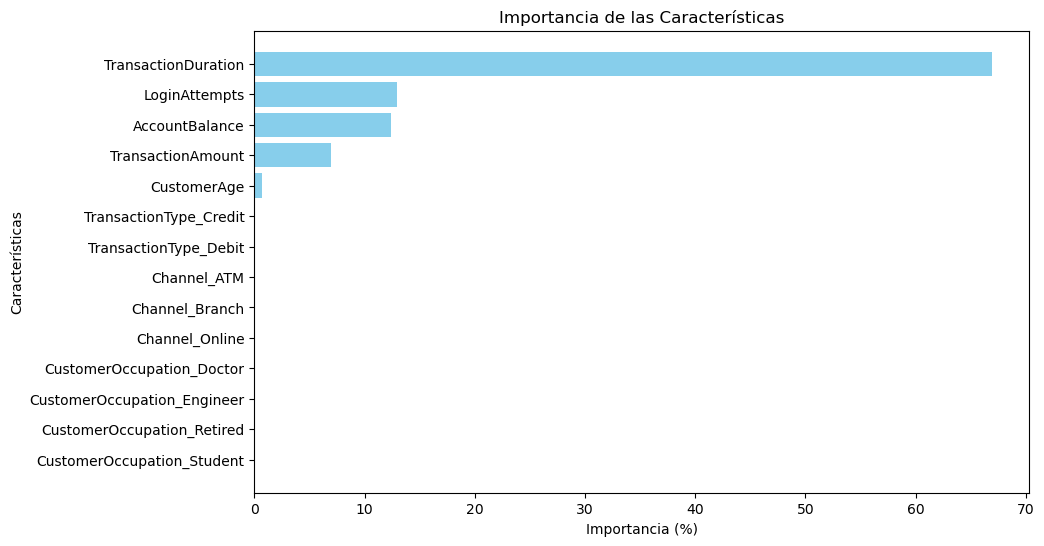

In [70]:
# Creamos el gráfico
plt.figure(figsize=(10,6))
plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
plt.xlabel('Importancia (%)')
plt.ylabel('Características')
plt.title('Importancia de las Características')
plt.gca().invert_yaxis()
plt.show()


##### Vemos que la variable que más explica la predictividad del modelo es la TransactionDuration, por otro lado el resto de las variables que tienen algún peso en la predictividad son las variables que habíamos tenido en cuenta para definir el criterio de que un cliente es malo o no. El resto de variables categoricas que transformamos con one hot encoder no nos aportó ningún grado de predictividad.

## Coclusión Final

##### Lamentablemente, si bien los resultados del modelo son exepcionales, no podemos confiar en que esa predicción sea efectiva ya que lo más probable es que esté sobreajustando y que tenga una muy mala performance cuando lo pasemos a producción.

##### Mi recomendación es, buscar más datos para tener otros datos distintos de entrenamiento y testeo o ajustar el criterio de "Cliente Sospechoso" porque puede ser que nos esté quedando corto ese criterio.